# Tehran House Price Prediction

## Project Overview
This project analyzes real estate data from approximately 4000 apartments in Tehran.
Using features like area, number of rooms, amenities (parking, warehouse, elevator),
and location, we build a regression model to predict apartment prices.

## Dataset Features
- **Area**: Apartment size in square meters
- **Room**: Number of bedrooms
- **Parking / Warehouse / Elevator**: Boolean amenities
- **Address**: Approximate location in Tehran
- **Price**: Price in Iranian Toman
- **Price(USD)**: Price in US Dollars

## 1. Importing Libraries

In [65]:
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np
%matplotlib inline

## 2. Loading & Exploring Data

In [66]:
df = pd.read_csv("House_Price_Predict.csv")

In [67]:
df.dtypes

Area           object
Room            int64
Parking          bool
Warehouse        bool
Elevator         bool
Address        object
Price         float64
Price(USD)    float64
dtype: object

## 3. Data Cleaning
- Remove rows with missing Address
- Convert Area column from string to float
- Remove outliers (Area > 700 m²)
- Remove duplicate rows

In [68]:
df['Area'].unique()
df['Area'].sample(20)

926      54
3099     87
1984    235
3349     80
1549    104
2244     47
914      58
634     124
2196     80
495     105
964     125
2110     55
2800     68
2500     75
867      74
992      93
960     105
220     166
1391     67
1860    105
Name: Area, dtype: object

In [69]:
df['Address'].isna().sum()

np.int64(23)

In [70]:
df = df.dropna(subset=['Address'])
df.shape

(3456, 8)

In [71]:
df['Area'] = df['Area'].str.replace(',', '', regex=False)
df['Area'] = df['Area'].astype(float)

In [72]:
df['Area'].describe()

count    3.456000e+03
mean     8.802191e+06
std      3.177783e+08
min      3.000000e+01
25%      6.900000e+01
50%      9.000000e+01
75%      1.210000e+02
max      1.616000e+10
Name: Area, dtype: float64

In [73]:
df['Area'].sort_values(ascending=False).head(20)

709     1.616000e+10
1604    8.400000e+09
570     3.310000e+09
2802    2.550000e+09
2171    3.600000e+03
807     1.000000e+03
1694    9.290000e+02
1974    9.000000e+02
573     8.630000e+02
3115    7.500000e+02
831     7.500000e+02
1810    7.050000e+02
2647    7.000000e+02
2481    7.000000e+02
819     6.800000e+02
431     6.600000e+02
356     6.500000e+02
3107    6.300000e+02
3000    6.000000e+02
1236    6.000000e+02
Name: Area, dtype: float64

In [74]:
df = df[df['Area'] <= 700]

In [75]:
df.shape

(3444, 8)

In [76]:
df.duplicated().sum()

np.int64(208)

In [77]:
df = df.drop_duplicates()

df.shape

(3236, 8)

In [78]:
df.isna().sum()

Area          0
Room          0
Parking       0
Warehouse     0
Elevator      0
Address       0
Price         0
Price(USD)    0
dtype: int64

In [79]:
df.dtypes

Area          float64
Room            int64
Parking          bool
Warehouse        bool
Elevator         bool
Address        object
Price         float64
Price(USD)    float64
dtype: object

In [80]:
df.shape

(3236, 8)

## 4. Exploratory Data Analysis (EDA)

<Axes: >

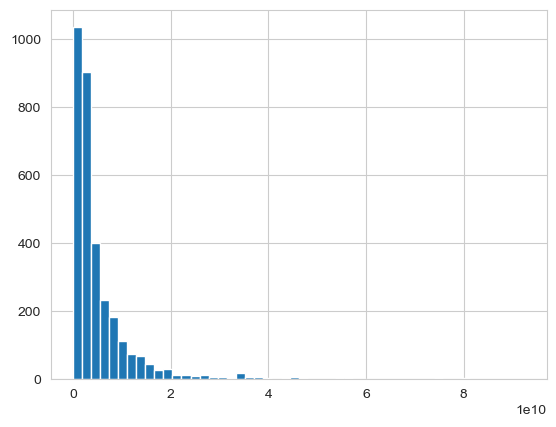

In [81]:
df['Price'].hist(bins=50)

<Axes: >

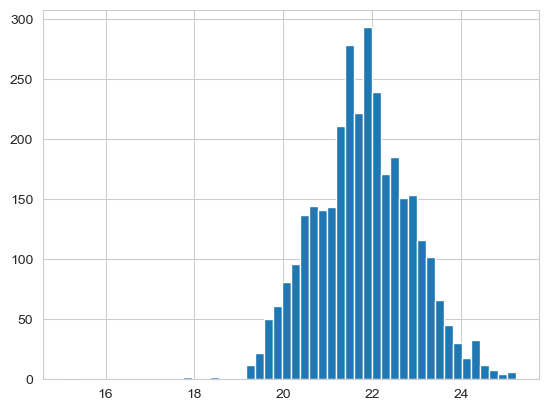

In [82]:
np.log1p(df['Price']).hist(bins=50)

<Axes: xlabel='Area', ylabel='Price'>

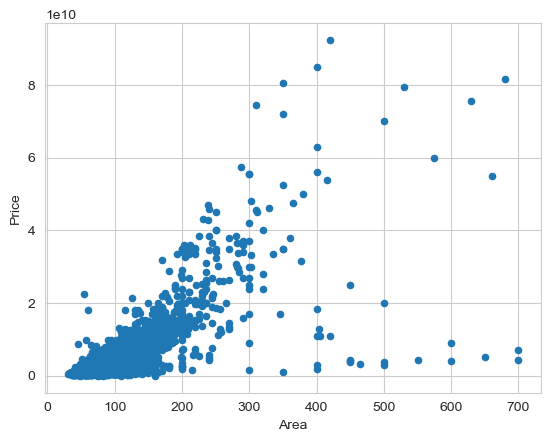

In [83]:
df.plot.scatter(x='Area', y='Price')

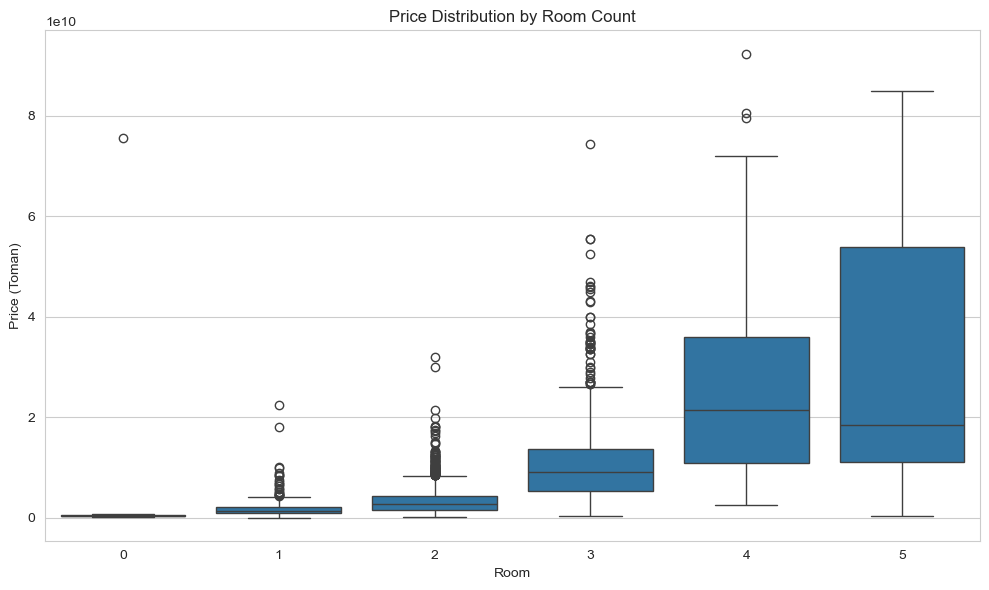

In [84]:
import seaborn as sns
sns.set_style('whitegrid')
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Room', y='Price')
plt.title('Price Distribution by Room Count')
plt.xlabel('Room')
plt.ylabel('Price (Toman)')
plt.tight_layout()
plt.savefig('room_price_boxplot.png', dpi=150)
plt.show()

In [85]:
df.groupby('Parking')['Price'].mean()

Parking
False    1.729368e+09
True     6.075901e+09
Name: Price, dtype: float64

In [86]:
df.groupby('Warehouse')['Price'].mean()

Warehouse
False    2.519745e+09
True     5.672471e+09
Name: Price, dtype: float64

In [87]:
df.groupby('Elevator')['Price'].mean()

Elevator
False    3.483685e+09
True     5.922370e+09
Name: Price, dtype: float64

## 5. Feature Engineering

In [88]:
df['Parking'] = df['Parking'].astype(int)
df['Warehouse'] = df['Warehouse'].astype(int)
df['Elevator'] = df['Elevator'].astype(int)

In [89]:
df[['Parking', 'Warehouse', 'Elevator']].head()

,Parking,Warehouse,Elevator
0,1,1,1
1,1,1,1
2,1,1,1
3,1,1,1
4,1,1,1


In [90]:
df['Address'].value_counts()

Address
Punak                     148
West Ferdows Boulevard    133
Gheitarieh                131
Shahran                   123
Pardis                    123
                         ... 
Islamshahr Elahieh          1
Ray - Montazeri             1
Firoozkooh Kuhsar           1
Mehrabad                    1
Yakhchiabad                 1
Name: count, Length: 191, dtype: int64

In [91]:
df['Address'].value_counts().describe()

count    191.000000
mean      16.942408
std       29.162193
min        1.000000
25%        2.000000
50%        5.000000
75%       15.000000
max      148.000000
Name: count, dtype: float64

In [92]:
address_counts = df['Address'].value_counts()
rare_addresses = address_counts[address_counts < 10].index
df['Address'] = df['Address'].replace(rare_addresses, 'Other')

In [93]:
df['Address'].nunique()

67

In [94]:
df_encoded = pd.get_dummies(df, columns=['Address'], drop_first=True)

In [95]:
df_encoded.shape

(3236, 73)

In [96]:
df_encoded['Price_log'] = np.log1p(df_encoded['Price'])

X = df_encoded.drop(columns=['Price', 'Price(USD)', 'Price_log'])
y = df_encoded['Price_log']

In [97]:
X.shape, y.shape

((3236, 71), (3236,))

## 6. Train/Test Split

In [98]:
msk = np.random.rand(len(df_encoded)) < 0.8
train = df_encoded[msk]
test = df_encoded[~msk]

In [99]:
X_train = train.drop(columns=['Price', 'Price(USD)', 'Price_log'])
y_train = train['Price_log']

X_test = test.drop(columns=['Price', 'Price(USD)', 'Price_log'])
y_test = test['Price_log']

In [100]:
X_train.shape, X_test.shape

((2575, 71), (661, 71))

## 7. Model Training & Evaluation

In [101]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [102]:
y_pred = model.predict(X_test)

In [103]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.28036353721547885
RMSE: 0.4205390243246446
R2: 0.852481021798088


In [104]:
print("R2-score: %.2f" % r2_score(y_test, y_pred) )

R2-score: 0.85


## 8. Results Summary

In [105]:
print("=" * 40)
print("       MODEL EVALUATION RESULTS")
print("=" * 40)
print(f"  MAE  : {mae:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  R²   : {r2:.4f}")
print("=" * 40)
print("Note: Metrics are on log-scale of Price.")
print(f"  Train size : {X_train.shape[0]} samples")
print(f"  Test size  : {X_test.shape[0]} samples")
print(f"  Features   : {X_train.shape[1]}")

       MODEL EVALUATION RESULTS
  MAE  : 0.2804
  RMSE : 0.4205
  R²   : 0.8525
Note: Metrics are on log-scale of Price.
  Train size : 2575 samples
  Test size  : 661 samples
  Features   : 71
